In [1]:
import polars
import polars as pl
import numpy as np
DATA_BASE_PATH = "data/"

In [2]:
data = polars.read_csv(DATA_BASE_PATH + "node_information.csv")

In [3]:
# Read txt file containing the edges 
edges_df = polars.read_csv(DATA_BASE_PATH + "train.txt", separator=" ", has_header=False, new_columns=["a", "b", "label"])
edges_df.shape

(10496, 3)

### Feature source

In [4]:
# Create node_feature_mapping from node_id to feature vector (BoW)
node_table = polars.read_csv(DATA_BASE_PATH + "node_information.csv")

node_feature_mapping = {}
for row in node_table.iter_rows():
    node_id = int(row[0])
    features = np.array(row[1:], dtype=np.float32)
    node_feature_mapping[node_id] = features

print("Node features set to BoW:", len(node_feature_mapping), "nodes")

Node features set to BoW: 3596 nodes


In [5]:
## Function to apply PCA to the node features
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
def apply_pca(node_feature_mapping, n_components=100):
    node_ids = list(node_feature_mapping.keys())
    features = np.array(list(node_feature_mapping.values()))
    
    pca = PCA(n_components=n_components)
    reduced_features = pca.fit_transform(features)
    # Plot elbow curve to determine optimal number of components
    explained_variance = pca.explained_variance_ratio_
    plt.plot(np.cumsum(explained_variance))
    plt.xlabel('Number of Components')
    plt.ylabel('Cumulative Explained Variance')
    
    reduced_node_feature_mapping = {node_id: reduced_features[i] for i, node_id in enumerate(node_ids)}
    return reduced_node_feature_mapping

Standard interface to create dataset

In [6]:
def build_dataset(edges, labels, feature_builder):
    X = []
    Y = []
    unseen_nodes_count = 0
    for i in range(edges.shape[0]):
        a, b = edges[i]
        edge_features = feature_builder(a, b)
        if edge_features is not None:
            X.append(edge_features)
            Y.append(labels[i])
        else:
            unseen_nodes_count += 1
    print(f"Rows with >=1 unseen node: {unseen_nodes_count} / {edges.shape[0]}")
    return np.array(X), np.array(Y)

### Feature engineering

In [7]:
import math
import networkx as nx

# Graphe des liens positifs pour extraire des features topologiques
G_raw_topo = nx.Graph()
for row in edges_df.filter(pl.col("label") == 1).iter_rows(named=True):
    G_raw_topo.add_edge(int(row["a"]), int(row["b"]))

def topology_features(node_a, node_b):
    a = int(node_a)
    b = int(node_b)
    if a not in G_raw_topo or b not in G_raw_topo:
        return np.array([0.0, 0.0, 0.0], dtype=np.float32)

    common = list(nx.common_neighbors(G_raw_topo, a, b))
    cn = float(len(common))
    aa = 0.0
    ra = 0.0

    for z in common:
        deg_z = G_raw_topo.degree(z)
        if deg_z > 1:
            aa += 1.0 / math.log(deg_z)
        if deg_z > 0:
            ra += 1.0 / deg_z

    return np.array([cn, aa, ra], dtype=np.float32)

def raw_feature_builder(node_a, node_b):
    features_a = node_feature_mapping.get(node_a)
    features_b = node_feature_mapping.get(node_b)
    if features_a is None or features_b is None:
        return None
    topo = topology_features(node_a, node_b)
    return np.concatenate([features_a, features_b])

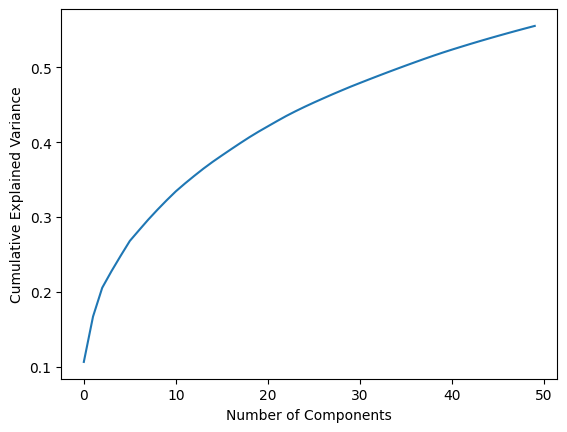

In [8]:
reduced_node_feature_mapping = apply_pca(node_feature_mapping, n_components=50)
def pca_feature_builder(node_a, node_b):
    features_a = reduced_node_feature_mapping.get(node_a)
    features_b = reduced_node_feature_mapping.get(node_b)
    if features_a is None or features_b is None:
        return None 
    return np.concatenate([features_a, features_b])

In [9]:
data = edges_df.to_numpy()
edges = data[:, :2]  # columns: a, b
labels = data[:, 2]  # column: label

X, Y = build_dataset(edges, labels, raw_feature_builder)
# X, Y = build_dataset(edges, labels, pca_feature_builder)

# X, Y = raw_diff_dataset()
print(X.shape, Y.shape)

# Split test and train (stratifie pour conserver la proportion des classes)
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.3, random_state=42, stratify=Y
)

Rows with >=1 unseen node: 7 / 10496
(10489, 1864) (10489,)


In [10]:
from sklearn.metrics import classification_report, roc_auc_score

def evaluate_model(model, x, y):
    y_predicted = model.predict(x)
    report = classification_report(y, y_predicted)

    # AUC sur probabilites si disponibles; fallback sur labels sinon
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(x)[:, 1]
    else:
        y_score = y_predicted

    auc_roc = roc_auc_score(y, y_score)
    print(report)
    print(f"AUC-ROC: {auc_roc:.4f}")

### SVM baseline

In [11]:
from sklearn.svm import SVC

clf = SVC()
# clf.fit(X_train, Y_train)

In [12]:
# evaluate_model(clf, X_test, Y_test)

### XGboost baseline

In [13]:
from xgboost import XGBClassifier

clf = XGBClassifier()
clf.fit(X_train, Y_train)



ModuleNotFoundError: No module named 'xgboost'

In [ ]:
evaluate_model(clf, X_test, Y_test)

              precision    recall  f1-score   support

           0       0.61      0.76      0.68      1573
           1       0.68      0.52      0.59      1574

    accuracy                           0.64      3147
   macro avg       0.65      0.64      0.63      3147
weighted avg       0.65      0.64      0.63      3147

AUC-ROC: 0.6789


### Logisitic regression

In [14]:
## Logistic Regression
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, Y_train)
evaluate_model(clf, X_test, Y_test)

              precision    recall  f1-score   support

           0       0.61      0.62      0.61      1573
           1       0.61      0.61      0.61      1574

    accuracy                           0.61      3147
   macro avg       0.61      0.61      0.61      3147
weighted avg       0.61      0.61      0.61      3147

AUC-ROC: 0.6597


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import networkx as nx

edges_np = edges_df.to_numpy()
edges_train_np, edges_test_np = train_test_split(
    edges_np,
    test_size=0.1,
    random_state=42,
    shuffle=True,
    stratify=edges_np[:, 2],
)

edges_train = pl.DataFrame(edges_train_np, schema=["a", "b", "label"]).with_columns(
    pl.col("a").cast(pl.Int64),
    pl.col("b").cast(pl.Int64),
    pl.col("label").cast(pl.Int64),
)
edges_test = pl.DataFrame(edges_test_np, schema=["a", "b", "label"]).with_columns(
    pl.col("a").cast(pl.Int64),
    pl.col("b").cast(pl.Int64),
    pl.col("label").cast(pl.Int64),
)

print("train/test sizes:", edges_train.shape, edges_test.shape)

train_pos = edges_train.filter(pl.col("label") == 1)
unique_nodes = set(train_pos["a"].to_list()) | set(train_pos["b"].to_list())
node_mapping = {node_id: i for i, node_id in enumerate(sorted(unique_nodes))}

G = nx.Graph()
for row in train_pos.iter_rows(named=True):
    u = node_mapping[row["a"]]
    v = node_mapping[row["b"]]
    G.add_edge(u, v)

print(f"Graph nodes (train positives): {G.number_of_nodes()}")
print(f"Graph edges (train positives): {G.number_of_edges()}")


def get_reduced_node_feature(node_id):
    features = reduced_node_feature_mapping.get(node_id)
    return features






train/test sizes: (9446, 3) (1050, 3)
Graph nodes (train positives): 3428
Graph edges (train positives): 4723


In [16]:
# Baseline topologique sans fuite: CN, AA, RA + XGBoost
import math
from xgboost import XGBClassifier

def pair_topology_features(node_u, node_v):
    u = node_mapping.get(int(node_u))
    v = node_mapping.get(int(node_v))
    if u is None or v is None:
        return [0.0, 0.0, 0.0]

    common = list(nx.common_neighbors(G, u, v))
    cn = float(len(common))

    aa = 0.0
    ra = 0.0
    for z in common:
        deg_z = G.degree(z)
        if deg_z > 1:
            aa += 1.0 / math.log(deg_z)
        if deg_z > 0:
            ra += 1.0 / deg_z

    return [cn, aa, ra]


def make_pair_dataset(edges_df, pair_builder):
    X = []
    y = []
    for row in edges_df.iter_rows(named=True):
        a = int(row["a"])

        b = int(row["b"])

        label = int(row["label"])

        X.append(pair_builder(a, b))
        y.append(label)
    return np.array(X, dtype=np.float32), np.array(y)





ModuleNotFoundError: No module named 'xgboost'

In [ ]:
# XGBoost sur features brutes + topologiques (CN/AA/RA)
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

# Petite validation interne pour reglages
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, Y_train, test_size=0.2, random_state=42, stratify=Y_train
)

xgb_raw = XGBClassifier(
    n_estimators=1200,
    max_depth=8,
    learning_rate=0.03,
    min_child_weight=3,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.1,
    device="cuda",
    reg_lambda=2.0,
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
    eval_metric="auc",
)

xgb_raw.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=False,
 )

evaluate_model(xgb_raw, X_test, Y_test)

              precision    recall  f1-score   support

           0       0.61      0.67      0.64      1573
           1       0.63      0.56      0.60      1574

    accuracy                           0.62      3147
   macro avg       0.62      0.62      0.62      3147
weighted avg       0.62      0.62      0.62      3147

AUC-ROC: 0.6587


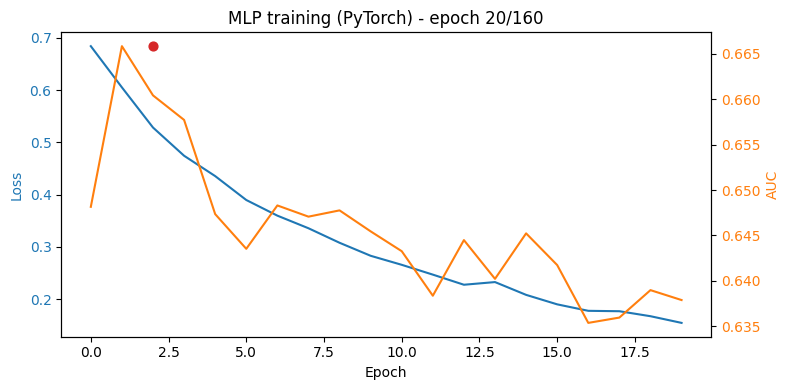

Device: cpu | Epoch 020 | loss=0.154675 | val_auc=0.637896 | best_auc=0.665823 (epoch 2)
Early stopping at epoch 20 (patience=18)

Best epoch: 2
Final validation report (best checkpoint):
              precision    recall  f1-score   support

           0       0.62      0.62      0.62      1049
           1       0.62      0.61      0.61      1049

    accuracy                           0.62      2098
   macro avg       0.62      0.62      0.62      2098
weighted avg       0.62      0.62      0.62      2098

Final validation AUC-ROC: 0.6658


In [17]:
# MLP train/val avec courbes live pendant l'entrainement (PyTorch + CUDA, anti-overfit)
import copy
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# Split stratifie
X_tr_mlp, X_val_mlp, y_tr_mlp, y_val_mlp = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)

# Normalisation
scaler_mlp = StandardScaler()
X_tr_mlp_s = scaler_mlp.fit_transform(X_tr_mlp).astype(np.float32)
X_val_mlp_s = scaler_mlp.transform(X_val_mlp).astype(np.float32)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

# Tensors + loader
X_tr_t = torch.tensor(X_tr_mlp_s, dtype=torch.float32)
y_tr_t = torch.tensor(y_tr_mlp.astype(np.float32), dtype=torch.float32)
X_val_t = torch.tensor(X_val_mlp_s, dtype=torch.float32).to(device)

train_ds = TensorDataset(X_tr_t, y_tr_t)
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)

# MLP plus regulier pour limiter l'overfit
in_dim = X_tr_mlp_s.shape[1]
mlp_core = nn.Sequential(
    nn.Linear(in_dim, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(0.35),
    nn.Linear(256, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Dropout(0.30),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Dropout(0.20),
    nn.Linear(64, 1),
).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(mlp_core.parameters(), lr=8e-4, weight_decay=3e-4)

max_epochs = 160
patience = 18
losses = []
val_aucs = []

best_auc = -1.0
best_epoch = 0
best_state = None
wait = 0

for epoch in range(1, max_epochs + 1):
    mlp_core.train()
    running_loss = 0.0
    n_samples = 0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits = mlp_core(xb).squeeze(1)
        loss = criterion(logits, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        bs = xb.size(0)
        running_loss += loss.item() * bs
        n_samples += bs

    train_loss = running_loss / max(n_samples, 1)

    mlp_core.eval()
    with torch.no_grad():
        val_logits = mlp_core(X_val_t).squeeze(1)
        val_proba = torch.sigmoid(val_logits).detach().cpu().numpy()
    val_auc = roc_auc_score(y_val_mlp, val_proba)

    losses.append(train_loss)
    val_aucs.append(val_auc)

    # Early stopping sur meilleure AUC validation
    if val_auc > best_auc + 1e-5:
        best_auc = val_auc
        best_epoch = epoch
        best_state = copy.deepcopy(mlp_core.state_dict())
        wait = 0
    else:
        wait += 1

    clear_output(wait=True)
    fig, ax1 = plt.subplots(figsize=(8, 4))
    ax1.plot(losses, label='Train loss', color='tab:blue')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')

    ax2 = ax1.twinx()
    ax2.plot(val_aucs, label='Val AUC', color='tab:orange')
    ax2.set_ylabel('AUC', color='tab:orange')
    ax2.tick_params(axis='y', labelcolor='tab:orange')

    if best_epoch > 0:
        ax2.scatter([best_epoch], [best_auc], color='tab:red', s=40)

    plt.title(f'MLP training (PyTorch) - epoch {epoch}/{max_epochs}')
    plt.tight_layout()
    plt.show()

    print(
        f"Device: {device} | Epoch {epoch:03d} | loss={train_loss:.6f} | "
        f"val_auc={val_auc:.6f} | best_auc={best_auc:.6f} (epoch {best_epoch})"
    )

    if wait >= patience:
        print(f"Early stopping at epoch {epoch} (patience={patience})")
        break

# Restaure le meilleur modele
if best_state is not None:
    mlp_core.load_state_dict(best_state)

# Evaluation finale sur val
mlp_core.eval()
with torch.no_grad():
    val_logits = mlp_core(X_val_t).squeeze(1)
    y_val_proba = torch.sigmoid(val_logits).detach().cpu().numpy()

y_val_pred = (y_val_proba >= 0.5).astype(int)
print('\nBest epoch:', best_epoch)
print('Final validation report (best checkpoint):')
print(classification_report(y_val_mlp, y_val_pred))
print(f"Final validation AUC-ROC: {roc_auc_score(y_val_mlp, y_val_proba):.4f}")

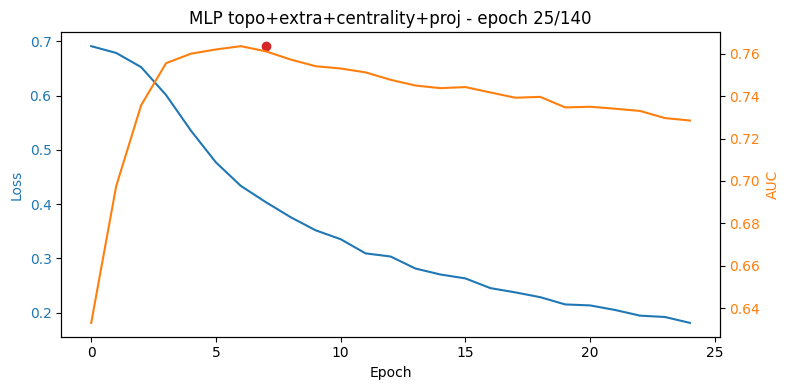

Device: cpu | Epoch 025 | loss=0.181186 | val_auc=0.728489 | best_auc=0.763551 (epoch 7)
Early stopping at epoch 25

Best epoch: 7
Validation report (best checkpoint):
              precision    recall  f1-score   support

           0       0.70      0.71      0.70      1049
           1       0.70      0.70      0.70      1049

    accuracy                           0.70      2098
   macro avg       0.70      0.70      0.70      2098
weighted avg       0.70      0.70      0.70      2098

Validation AUC-ROC: 0.7636


In [18]:
# MLP + couche de projection + features topologiques enrichies (CUDA)
import math
import copy
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# Build dataset enrichi: [fa, fb, topo, extra_sim, centralites]
edges_all = edges_df.to_numpy()

# Centralites globales sur le graphe positif
pagerank_map = nx.pagerank(G_raw_topo, alpha=0.85)
katz_map = nx.katz_centrality(G_raw_topo, alpha=0.005, beta=1.0, max_iter=1000, tol=1e-6)

def topo_feats(a, b):
    a = int(a); b = int(b)
    if a not in G_raw_topo or b not in G_raw_topo:
        return np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], dtype=np.float32)

    common = list(nx.common_neighbors(G_raw_topo, a, b))
    cn = float(len(common))
    aa = 0.0
    ra = 0.0
    for z in common:
        deg = G_raw_topo.degree(z)
        if deg > 1:
            aa += 1.0 / math.log(deg)
        if deg > 0:
            ra += 1.0 / deg

    na = set(G_raw_topo.neighbors(a))
    nb = set(G_raw_topo.neighbors(b))
    inter = len(na & nb)
    union = len(na | nb)
    jac = float(inter / union) if union > 0 else 0.0
    pa = float(len(na) * len(nb))

    # Infos de degre/noeud local
    deg_a = float(len(na))
    deg_b = float(len(nb))
    deg_diff = abs(deg_a - deg_b)

    # Compression de l'echelle pour AA/RA/PA
    return np.array([
        cn,
        np.log1p(aa),
        np.log1p(ra),
        jac,
        np.log1p(pa),
        np.log1p(deg_a),
        np.log1p(deg_b),
        np.log1p(deg_diff),
    ], dtype=np.float32)

def centrality_feats(a, b):
    a = int(a); b = int(b)
    pr_a = float(pagerank_map.get(a, 0.0))
    pr_b = float(pagerank_map.get(b, 0.0))
    kz_a = float(katz_map.get(a, 0.0))
    kz_b = float(katz_map.get(b, 0.0))
    return np.array([
        np.log1p(pr_a), np.log1p(pr_b), np.log1p(abs(pr_a - pr_b)),
        np.log1p(kz_a), np.log1p(kz_b), np.log1p(abs(kz_a - kz_b)),
    ], dtype=np.float32)

def extra_pair_feats(fa, fb):
    diff = fa - fb
    abs_diff = np.abs(diff)
    prod = fa * fb

    l1 = float(abs_diff.sum())
    l2 = float(np.sqrt((diff ** 2).sum()))
    cos = float(np.dot(fa, fb) / (np.linalg.norm(fa) * np.linalg.norm(fb) + 1e-8))
    dot = float(np.dot(fa, fb))

    mean_abs = float(abs_diff.mean())
    max_abs = float(abs_diff.max())
    mean_prod = float(prod.mean())
    std_prod = float(prod.std())

    return np.array([l1, l2, cos, dot, mean_abs, max_abs, mean_prod, std_prod], dtype=np.float32)

X_topo = []
Y_topo = []
for i in range(edges_all.shape[0]):
    a, b, y = edges_all[i]
    fa = node_feature_mapping.get(int(a))
    fb = node_feature_mapping.get(int(b))
    if fa is None or fb is None:
        continue
    topo = topo_feats(a, b)
    extra = extra_pair_feats(fa, fb)
    cent = centrality_feats(a, b)
    X_topo.append(np.concatenate([fa, fb, topo, extra, cent]).astype(np.float32))
    Y_topo.append(int(y))

X_topo = np.array(X_topo, dtype=np.float32)
Y_topo = np.array(Y_topo, dtype=np.int64)
print('Topo+extra+centrality dataset shape:', X_topo.shape, Y_topo.shape)

# Split
X_tr, X_val, y_tr, y_val = train_test_split(
    X_topo, Y_topo, test_size=0.2, random_state=42, stratify=Y_topo
)

# Scale
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr).astype(np.float32)
X_val_s = scaler.transform(X_val).astype(np.float32)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

train_ds = TensorDataset(
    torch.tensor(X_tr_s, dtype=torch.float32),
    torch.tensor(y_tr.astype(np.float32), dtype=torch.float32),
)
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
X_val_t = torch.tensor(X_val_s, dtype=torch.float32).to(device)

# Modele avec couche de projection (reduction de dimension)
class MLPTopoProj(nn.Module):
    def __init__(self, in_dim, proj_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, proj_dim),
            nn.BatchNorm1d(proj_dim),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(proj_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.net(x)

model = MLPTopoProj(in_dim=X_tr_s.shape[1], proj_dim=64).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=5e-3)

max_epochs = 140
patience = 18
losses, val_aucs = [], []
best_auc, best_epoch = -1.0, 0
best_state = None
wait = 0

for epoch in range(1, max_epochs + 1):
    model.train()
    run_loss = 0.0
    n = 0
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        logits = model(xb).squeeze(1)
        loss = criterion(logits, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        bs = xb.size(0)
        run_loss += loss.item() * bs
        n += bs

    train_loss = run_loss / max(n, 1)

    model.eval()
    with torch.no_grad():
        val_logits = model(X_val_t).squeeze(1)
        val_proba = torch.sigmoid(val_logits).detach().cpu().numpy()
    val_auc = roc_auc_score(y_val, val_proba)

    losses.append(train_loss)
    val_aucs.append(val_auc)

    if val_auc > best_auc + 1e-5:
        best_auc = val_auc
        best_epoch = epoch
        best_state = copy.deepcopy(model.state_dict())
        wait = 0
    else:
        wait += 1

    clear_output(wait=True)
    fig, ax1 = plt.subplots(figsize=(8, 4))
    ax1.plot(losses, color='tab:blue')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')

    ax2 = ax1.twinx()
    ax2.plot(val_aucs, color='tab:orange')
    ax2.set_ylabel('AUC', color='tab:orange')
    ax2.tick_params(axis='y', labelcolor='tab:orange')

    if best_epoch > 0:
        ax2.scatter([best_epoch], [best_auc], color='tab:red', s=36)

    plt.title(f'MLP topo+extra+centrality+proj - epoch {epoch}/{max_epochs}')
    plt.tight_layout()
    plt.show()

    print(
        f"Device: {device} | Epoch {epoch:03d} | loss={train_loss:.6f} | "
        f"val_auc={val_auc:.6f} | best_auc={best_auc:.6f} (epoch {best_epoch})"
    )

    if wait >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

if best_state is not None:
    model.load_state_dict(best_state)

model.eval()
with torch.no_grad():
    val_logits = model(X_val_t).squeeze(1)
    y_val_proba = torch.sigmoid(val_logits).detach().cpu().numpy()
y_val_pred = (y_val_proba >= 0.5).astype(int)

print('\nBest epoch:', best_epoch)
print('Validation report (best checkpoint):')
print(classification_report(y_val, y_val_pred))
print(f"Validation AUC-ROC: {roc_auc_score(y_val, y_val_proba):.4f}")

In [ ]:
# Submission avec MLP topo+extra+centrality+projection (train full)
import math
import numpy as np
import polars as pl
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

# 1) Centralites globales + features topo/extra (meme schema que la cellule validation)
pagerank_map = nx.pagerank(G_raw_topo, alpha=0.85)
katz_map = nx.katz_centrality(G_raw_topo, alpha=0.005, beta=1.0, max_iter=1000, tol=1e-6)

def topo_feats_submit(a, b):
    a = int(a); b = int(b)
    if a not in G_raw_topo or b not in G_raw_topo:
        return np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], dtype=np.float32)

    common = list(nx.common_neighbors(G_raw_topo, a, b))
    cn = float(len(common))
    aa = 0.0
    ra = 0.0
    for z in common:
        deg = G_raw_topo.degree(z)
        if deg > 1:
            aa += 1.0 / math.log(deg)
        if deg > 0:
            ra += 1.0 / deg

    na = set(G_raw_topo.neighbors(a))
    nb = set(G_raw_topo.neighbors(b))
    inter = len(na & nb)
    union = len(na | nb)
    jac = float(inter / union) if union > 0 else 0.0
    pa = float(len(na) * len(nb))

    deg_a = float(len(na))
    deg_b = float(len(nb))
    deg_diff = abs(deg_a - deg_b)

    return np.array([
        cn,
        np.log1p(aa),
        np.log1p(ra),
        jac,
        np.log1p(pa),
        np.log1p(deg_a),
        np.log1p(deg_b),
        np.log1p(deg_diff),
    ], dtype=np.float32)

def centrality_feats_submit(a, b):
    a = int(a); b = int(b)
    pr_a = float(pagerank_map.get(a, 0.0))
    pr_b = float(pagerank_map.get(b, 0.0))
    kz_a = float(katz_map.get(a, 0.0))
    kz_b = float(katz_map.get(b, 0.0))
    return np.array([
        np.log1p(pr_a), np.log1p(pr_b), np.log1p(abs(pr_a - pr_b)),
        np.log1p(kz_a), np.log1p(kz_b), np.log1p(abs(kz_a - kz_b)),
    ], dtype=np.float32)

def extra_pair_feats_submit(fa, fb):
    diff = fa - fb
    abs_diff = np.abs(diff)
    prod = fa * fb

    l1 = float(abs_diff.sum())
    l2 = float(np.sqrt((diff ** 2).sum()))
    cos = float(np.dot(fa, fb) / (np.linalg.norm(fa) * np.linalg.norm(fb) + 1e-8))
    dot = float(np.dot(fa, fb))

    mean_abs = float(abs_diff.mean())
    max_abs = float(abs_diff.max())
    mean_prod = float(prod.mean())
    std_prod = float(prod.std())

    return np.array([l1, l2, cos, dot, mean_abs, max_abs, mean_prod, std_prod], dtype=np.float32)

# 2) Build train full
train_np = edges_df.to_numpy()
X_full = []
y_full = []
for i in range(train_np.shape[0]):
    a, b, y = train_np[i]
    fa = node_feature_mapping.get(int(a))
    fb = node_feature_mapping.get(int(b))
    if fa is None or fb is None:
        continue
    topo = topo_feats_submit(a, b)
    extra = extra_pair_feats_submit(fa, fb)
    cent = centrality_feats_submit(a, b)
    X_full.append(np.concatenate([fa, fb, topo, extra, cent]).astype(np.float32))
    y_full.append(int(y))

X_full = np.array(X_full, dtype=np.float32)
y_full = np.array(y_full, dtype=np.float32)
print('Full train shape:', X_full.shape, y_full.shape)

# 3) Build test
test_df = pl.read_csv(DATA_BASE_PATH + 'test.txt', separator=' ', has_header=False, new_columns=['a', 'b'])
test_np = test_df.to_numpy()
X_submit = []
for i in range(test_np.shape[0]):
    a, b = test_np[i]
    fa = node_feature_mapping.get(int(a))
    fb = node_feature_mapping.get(int(b))
    if fa is None or fb is None:
        fa = np.zeros_like(next(iter(node_feature_mapping.values())), dtype=np.float32)
        fb = np.zeros_like(next(iter(node_feature_mapping.values())), dtype=np.float32)
    topo = topo_feats_submit(a, b)
    extra = extra_pair_feats_submit(fa, fb)
    cent = centrality_feats_submit(a, b)
    X_submit.append(np.concatenate([fa, fb, topo, extra, cent]).astype(np.float32))
X_submit = np.array(X_submit, dtype=np.float32)
print('Submit shape:', X_submit.shape)

# 4) Scale
scaler_full = StandardScaler()
X_full_s = scaler_full.fit_transform(X_full).astype(np.float32)
X_submit_s = scaler_full.transform(X_submit).astype(np.float32)

# 5) Modele (meme archi)
class MLPTopoProjSubmit(nn.Module):
    def __init__(self, in_dim, proj_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, proj_dim),
            nn.BatchNorm1d(proj_dim),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(proj_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(32, 1),
        )
    def forward(self, x):
        return self.net(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

model_submit = MLPTopoProjSubmit(in_dim=X_full_s.shape[1], proj_dim=64).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model_submit.parameters(), lr=2e-4, weight_decay=5e-3)

# best epoch observe en validation ~= 6
epochs_full = 6
train_ds = TensorDataset(
    torch.tensor(X_full_s, dtype=torch.float32),
    torch.tensor(y_full, dtype=torch.float32),
)
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)

for epoch in range(1, epochs_full + 1):
    model_submit.train()
    run_loss = 0.0
    n = 0
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        logits = model_submit(xb).squeeze(1)
        loss = criterion(logits, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        bs = xb.size(0)
        run_loss += loss.item() * bs
        n += bs
    print(f'Epoch {epoch:02d}/{epochs_full} | loss={run_loss / max(n,1):.6f}')

# 6) Predict submit
model_submit.eval()
with torch.no_grad():
    x_sub_t = torch.tensor(X_submit_s, dtype=torch.float32).to(device)
    logits_sub = model_submit(x_sub_t).squeeze(1)
    proba_sub = torch.sigmoid(logits_sub).cpu().numpy()
pred_sub = (proba_sub >= 0.5).astype(int)

submission_proba = pl.DataFrame({'ID': np.arange(len(proba_sub)), 'Predicted': proba_sub})
submission_label = pl.DataFrame({'ID': np.arange(len(pred_sub)), 'Predicted': pred_sub})

submission_proba.write_csv('data/submission_mlp_topo_extra_centrality_proba.csv')
submission_label.write_csv('data/submission_mlp_topo_extra_centrality_label.csv')

print('Saved: data/submission_mlp_topo_extra_centrality_proba.csv')
print('Saved: data/submission_mlp_topo_extra_centrality_label.csv')
submission_proba.head()

Full train shape: (10489, 1887) (10489,)
Submit shape: (3498, 1887)
Device: cuda
Epoch 01/6 | loss=0.692655
Epoch 02/6 | loss=0.675220
Epoch 03/6 | loss=0.636863
Epoch 04/6 | loss=0.568554
Epoch 05/6 | loss=0.504196
Epoch 06/6 | loss=0.460469
Saved: data/submission_mlp_topo_extra_centrality_proba.csv
Saved: data/submission_mlp_topo_extra_centrality_label.csv


ID,Predicted
i64,f32
0,0.130336
1,0.164192
2,0.027596
3,0.264698
4,0.229439
